# FRBLikelihood — evaluating the log-likelihood for an FRB catalogue

This notebook demonstrates how to use the `FRBLikelihood` class to evaluate the log-posterior for a set of cosmological and astrophysical parameters given an FRB catalogue.  It also shows how to run a simple MCMC with `emcee`.

### Parameter vector convention

| index | symbol | description |
|-------|--------|-------------|
| 0 | DM_host | mean host-galaxy DM [pc/cm³] |
| 1 | σ_host | scatter of host DM [pc/cm³] |
| 2 | log T_AGN | baryonic feedback parameter |
| 3 | ω_b | physical baryon density ω_b = Ω_b h² |
| 4 | ω_c | physical CDM density ω_c = Ω_c h² |
| 5 | σ_8 | matter fluctuation amplitude |
| 6 | n_s | spectral index |
| 7 | h | dimensionless Hubble constant |
| (8) | f_IGM | fraction of baryons in the IGM — only for `log_likelihood_figm_marginalized` |

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.coordinates as coord
import astropy.units as units
import cosmopower as cp
from frb_cov import FRBLikelihood

## 1  Load the cosmopower emulators

In [16]:
bias_emu      = cp.cosmopower_NN(restore=True, restore_filename="../cosmopower/bias_sq_model")
power_emu     = cp.cosmopower_NN(restore=True, restore_filename="../cosmopower/pkmm_nonlin_model")
power_lin_emu = cp.cosmopower_NN(restore=True, restore_filename="../cosmopower/pkmm_lin_model")

## 2  Load and prepare the FRB catalogue

In [17]:
df = pd.read_csv("../data/00.New_FRB_Data.csv")

DM_obs = df['DMobs'].values.astype(float)
DM_MW  = df['DMmw'].values.astype(float)
zet    = df['Redshift'].values.astype(float)
ra     = coord.Angle(df['RA'].values,  unit=units.degree).radian - np.pi
dec    = coord.Angle(df['DEC'].values, unit=units.degree).radian

# Remove duplicate redshifts and apply a basic quality cut
idx = np.sort(np.unique(zet, return_index=True)[1])
DM_obs, DM_MW, zet, ra, dec = DM_obs[idx], DM_MW[idx], zet[idx], ra[idx], dec[idx]
mask = np.logical_or(DM_obs < 1000, zet > 0.4)
DM_obs, DM_MW, zet, ra, dec = DM_obs[mask], DM_MW[mask], zet[mask], ra[mask], dec[mask]

print(f"{len(zet)} FRBs  |  z in [{zet.min():.3f}, {zet.max():.3f}]")

69 FRBs  |  z in [0.105, 1.354]


## 3  Build the Planck prior

We fit a multivariate Gaussian to the published Planck MCMC chain.  
The five parameters are *(ω_b, ω_c, σ_8, n_s, h)* — matching the last five elements of the `params` vector.

In [18]:
planck_chain = np.loadtxt("../data/base_plikHM_TTTEEE_lowl_lowE_lensing_1.txt")

# columns: col 2 = omega_b, col 3 = omega_c, col 36 = sigma_8, col 7 = n_s, col 30 = h
planck_par = np.column_stack([
    planck_chain[:, 2],   # omega_b
    planck_chain[:, 3],   # omega_c
    planck_chain[:, 36],  # sigma_8
    planck_chain[:, 7],   # n_s
    planck_chain[:, 30],  # h
])

planck_mean = np.mean(planck_par, axis=0)
planck_cov  = np.cov(planck_par.T)

labels = [r'$\omega_b$', r'$\omega_c$', r'$\sigma_8$', r'$n_s$', r'$h$']
print("Planck posterior means:")
for lab, val in zip(labels, planck_mean):
    print(f"  {lab:12s} = {val:.5f}")

Planck posterior means:
  $\omega_b$   = 0.02237
  $\omega_c$   = 0.12009
  $\sigma_8$   = 0.83226
  $n_s$        = 0.96462
  $h$          = 0.68411


## 4  Instantiate FRBLikelihood

`FRBLikelihood` pre-computes the angular-separation matrix `delta_theta` in its constructor, so you only pay that cost once.

In [19]:
likelihood = FRBLikelihood(
    DM_obs        = DM_obs,
    DM_MW         = DM_MW,
    redshifts     = zet,
    ra            = ra,
    dec           = dec,
    bias_emu      = bias_emu,
    power_emu     = power_emu,
    power_lin_emu = power_lin_emu,
    planck_mean   = planck_mean,
    planck_cov    = planck_cov,
    # Override any fixed cosmological parameters that differ from the defaults:
    cosmo_template = {'path_to_f_iGM': '../data/figm'},
)

## 5  Evaluate likelihoods at fiducial parameters

The `params` vector is assembled from:

```
[DM_host, sigma_host, logTAGN,  omega_b*h^2, omega_c*h^2, sigma_8, ns, h]
```

In [20]:
import time

h = planck_mean[4]
fiducial_params = np.array([
    100.0,           # DM_host  [pc/cm³]
    100.0,           # sigma_host [pc/cm³]
    7.8,             # logTAGN
    planck_mean[0],  # omega_b * h^2  (already physical)
    planck_mean[1],  # omega_c * h^2
    planck_mean[2],  # sigma_8
    planck_mean[3],  # n_s
    planck_mean[4],  # h
])

print("Fiducial params:", fiducial_params)
print()
likelihood.n_chi_limber = 100

lnl_basic = likelihood.log_likelihood(fiducial_params)


print(f"log_likelihood                          : {lnl_basic:.3f}")


Fiducial params: [1.00000000e+02 1.00000000e+02 7.80000000e+00 2.23685351e-02
 1.20091926e-01 8.32263853e-01 9.64621762e-01 6.84112471e-01]

log_likelihood                          : -412.787


### All five likelihood variants

In [21]:
methods = [
    ('Basic',                            likelihood.log_likelihood,
     dict(DM_MW_halo=50)),
    ('MW marginalised',                  likelihood.log_likelihood_mw_marginalized,
     dict(DM_MW_halo=50, rel_error_DM_MW=0.2)),
    ('With p_detect',                    likelihood.log_likelihood_with_pdetect,
     dict(DM_MW_halo=50, DMmax=1500)),
    ('MW marg + p_detect',               likelihood.log_likelihood_mw_marginalized_with_pdetect,
     dict(DM_MW_halo=50, rel_error_DM_MW=0.2, DMmax=1500)),
]

for name, method, kwargs in methods:
    lnl = method(fiducial_params, **kwargs)
    print(f"{name:40s}: {lnl:.3f}")

# figm variant needs an extra parameter
figm_params = np.append(fiducial_params, 1.0)  # f_IGM = 1
lnl_figm = likelihood.log_likelihood_figm_marginalized(figm_params, DM_MW_halo=50)
print(f"{'f_IGM marginalised':40s}: {lnl_figm:.3f}")

Basic                                   : -412.787
MW marginalised                         : -413.066
With p_detect                           : -411.829
MW marg + p_detect                      : -412.005
f_IGM marginalised                      : -412.097


## 6  1-D likelihood scan over log T_AGN

We vary `log T_AGN` while keeping all other parameters fixed at their fiducial values.

In [22]:
logT_grid = np.linspace(7.1, 8.5, 15)
lnl_grid  = np.zeros_like(logT_grid)

for i, logT in enumerate(logT_grid):
    p = fiducial_params.copy()
    p[2] = logT
    lnl_grid[i] = likelihood.log_likelihood(p)
    print(f"  logTAGN={logT:.2f}  lnL={lnl_grid[i]:.2f}")

best_idx = np.argmax(lnl_grid)
print(f"\nBest-fit logTAGN = {logT_grid[best_idx]:.2f}")

  logTAGN=7.10  lnL=-427.18
  logTAGN=7.20  lnL=-423.91
  logTAGN=7.30  lnL=-420.95
  logTAGN=7.40  lnL=-418.39
  logTAGN=7.50  lnL=-416.29
  logTAGN=7.60  lnL=-414.65
  logTAGN=7.70  lnL=-413.48
  logTAGN=7.80  lnL=-412.79
  logTAGN=7.90  lnL=-412.52
  logTAGN=8.00  lnL=-413.03
  logTAGN=8.10  lnL=-413.89
  logTAGN=8.20  lnL=-414.73
  logTAGN=8.30  lnL=-415.34
  logTAGN=8.40  lnL=-415.71
  logTAGN=8.50  lnL=-415.90

Best-fit logTAGN = 7.90


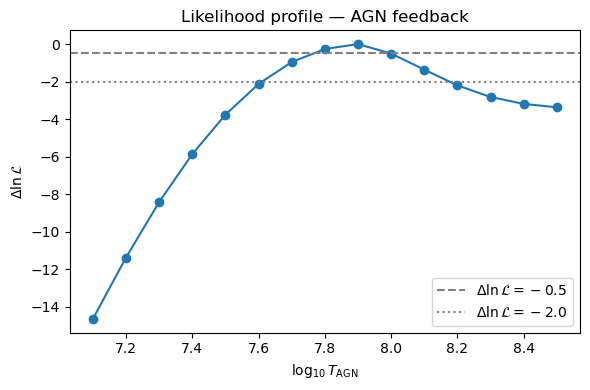

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(logT_grid, lnl_grid - lnl_grid.max(), 'o-')
ax.axhline(-0.5, ls='--', color='grey', label=r'$\Delta\ln\mathcal{L} = -0.5$')
ax.axhline(-2.0, ls=':',  color='grey', label=r'$\Delta\ln\mathcal{L} = -2.0$')
ax.set_xlabel(r'$\log_{10} T_{\rm AGN}$')
ax.set_ylabel(r'$\Delta \ln \mathcal{L}$')
ax.set_title('Likelihood profile — AGN feedback')
ax.legend()
plt.tight_layout()
plt.show()

## 7  MCMC with emcee

Below is a minimal example of how to pass `FRBLikelihood.log_likelihood` to `emcee`.  
The sampler needs a callable that takes only `params` (no extra arguments), which we wrap with a `lambda`.

In [28]:
import emcee
import os

ndim     = 8   # [DM_host, sigma_host, logTAGN, omega_b, omega_c, sigma_8, ns, h]
nwalkers = 32
target_steps = 2000

# Initialise walkers around the fiducial point
rng = np.random.default_rng(42)
pos = np.zeros((nwalkers, ndim))
pos[:, 0] = 100 + rng.standard_normal(nwalkers) * 5    # DM_host
pos[:, 1] = 100 + rng.standard_normal(nwalkers) * 5    # sigma_host
pos[:, 2] = 7.8 + rng.standard_normal(nwalkers) * 0.05 # logTAGN
pos[:, 3:] = rng.multivariate_normal(planck_mean, planck_cov, size=nwalkers)

# Wrap the likelihood so emcee only needs to pass params
log_prob = lambda p: likelihood.log_likelihood(p, DM_MW_halo=50)

output_file = "./results/mcmc/mcmc_basic.h5"

if os.path.exists(output_file):
    print(f"Found existing backend: {output_file}")
    backend = emcee.backends.HDFBackend(output_file, read_only=True)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, backend=backend)
    print(f"Stored steps: {backend.iteration}")
    print(f"Target steps: {target_steps}")
    print("Skipping run_mcmc and using existing chain from disk.")
else:
    print(f"No backend found at {output_file}. Running a new chain...")
    backend = emcee.backends.HDFBackend(output_file)
    backend.reset(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, backend=backend)
    sampler.run_mcmc(pos, target_steps, progress=True)

Found existing backend: ./results/mcmc/mcmc_basic.h5
Stored steps: 2000
Target steps: 2000
Skipping run_mcmc and using existing chain from disk.


In [25]:
# Discard burn-in and thin the chain
tau    = sampler.get_autocorr_time(quiet=True)
burnin = int(2 * np.max(tau))
thin   = max(1, int(0.5 * np.min(tau)))
flat_samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)
print(f"Flat samples shape: {flat_samples.shape}  (burn-in={burnin}, thin={thin})")

The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [89.15393636 86.99151781 73.2839354  77.32673164 78.8814751  71.01157738
 72.34326647 80.05943463]


Flat samples shape: (1664, 8)  (burn-in=178, thin=35)


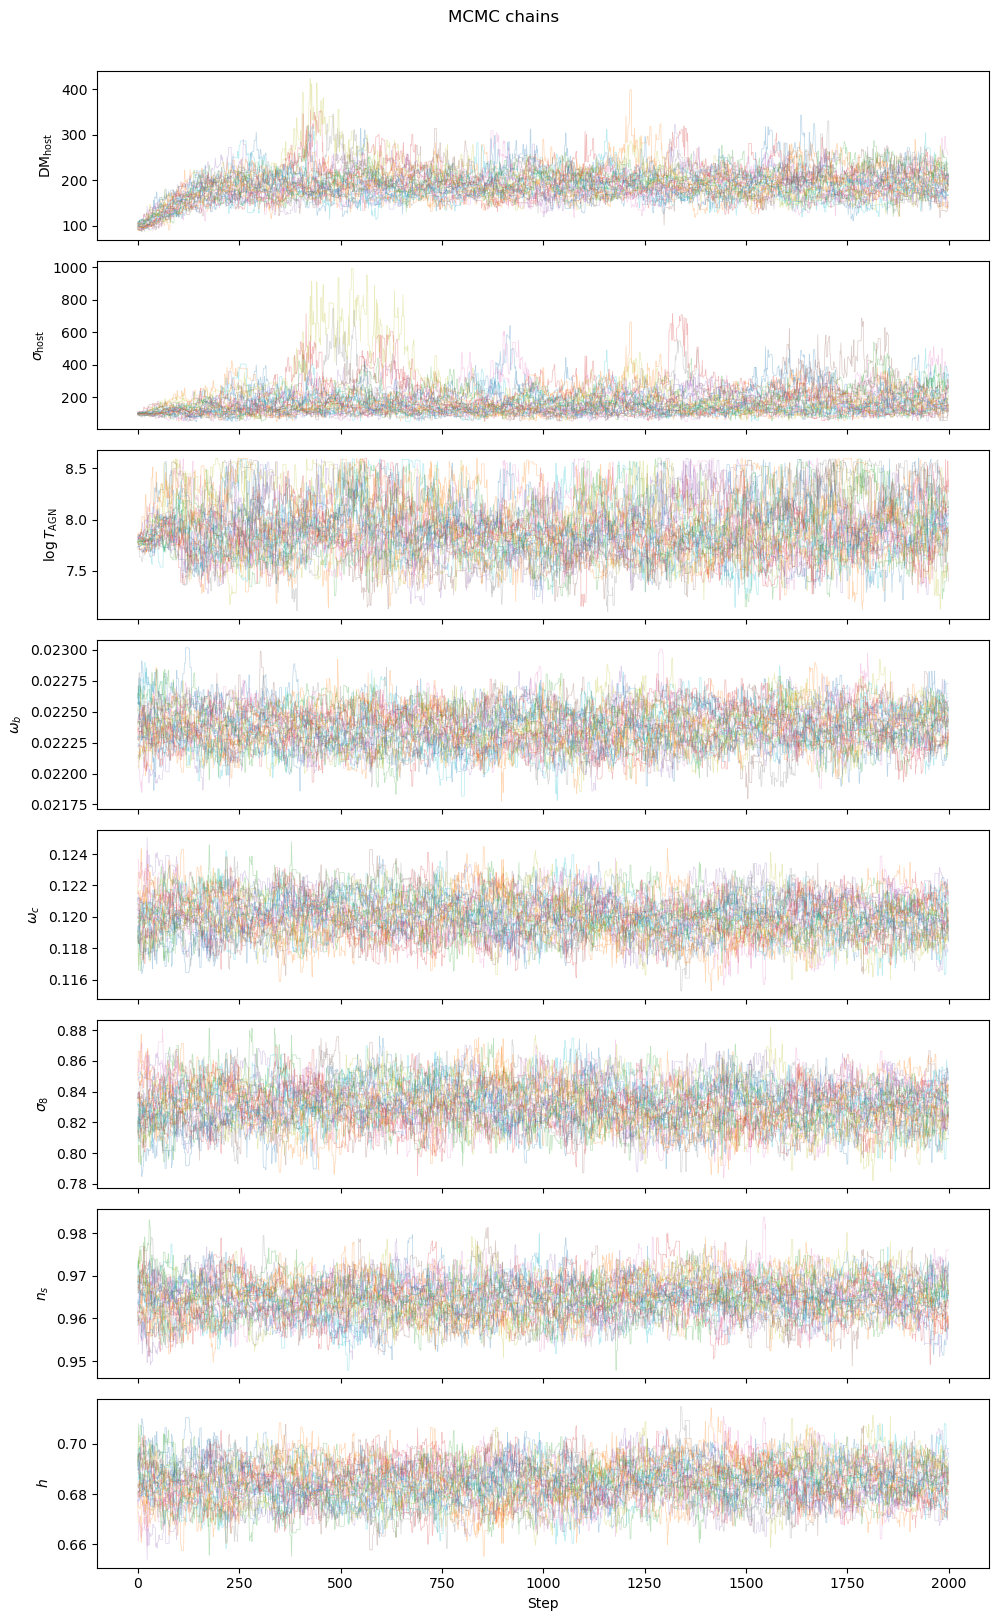

In [26]:
param_labels = [
    r'$\mathrm{DM}_{\rm host}$',
    r'$\sigma_{\rm host}$',
    r'$\log T_{\rm AGN}$',
    r'$\omega_b$',
    r'$\omega_c$',
    r'$\sigma_8$',
    r'$n_s$',
    r'$h$',
]

fig, axes = plt.subplots(ndim, figsize=(10, 2 * ndim), sharex=True)
chain = sampler.get_chain()
for i, (ax, lab) in enumerate(zip(axes, param_labels)):
    ax.plot(chain[:, :, i], alpha=0.3, lw=0.5)
    ax.set_ylabel(lab)
axes[-1].set_xlabel('Step')
fig.suptitle('MCMC chains', y=1.01)
plt.tight_layout()
plt.show()

## 8  Corner plot

The `corner` package produces a triangular matrix of
1-D marginal histograms on the diagonal and 2-D joint posteriors on the off-diagonal.
The fiducial values are overlaid as orange lines.

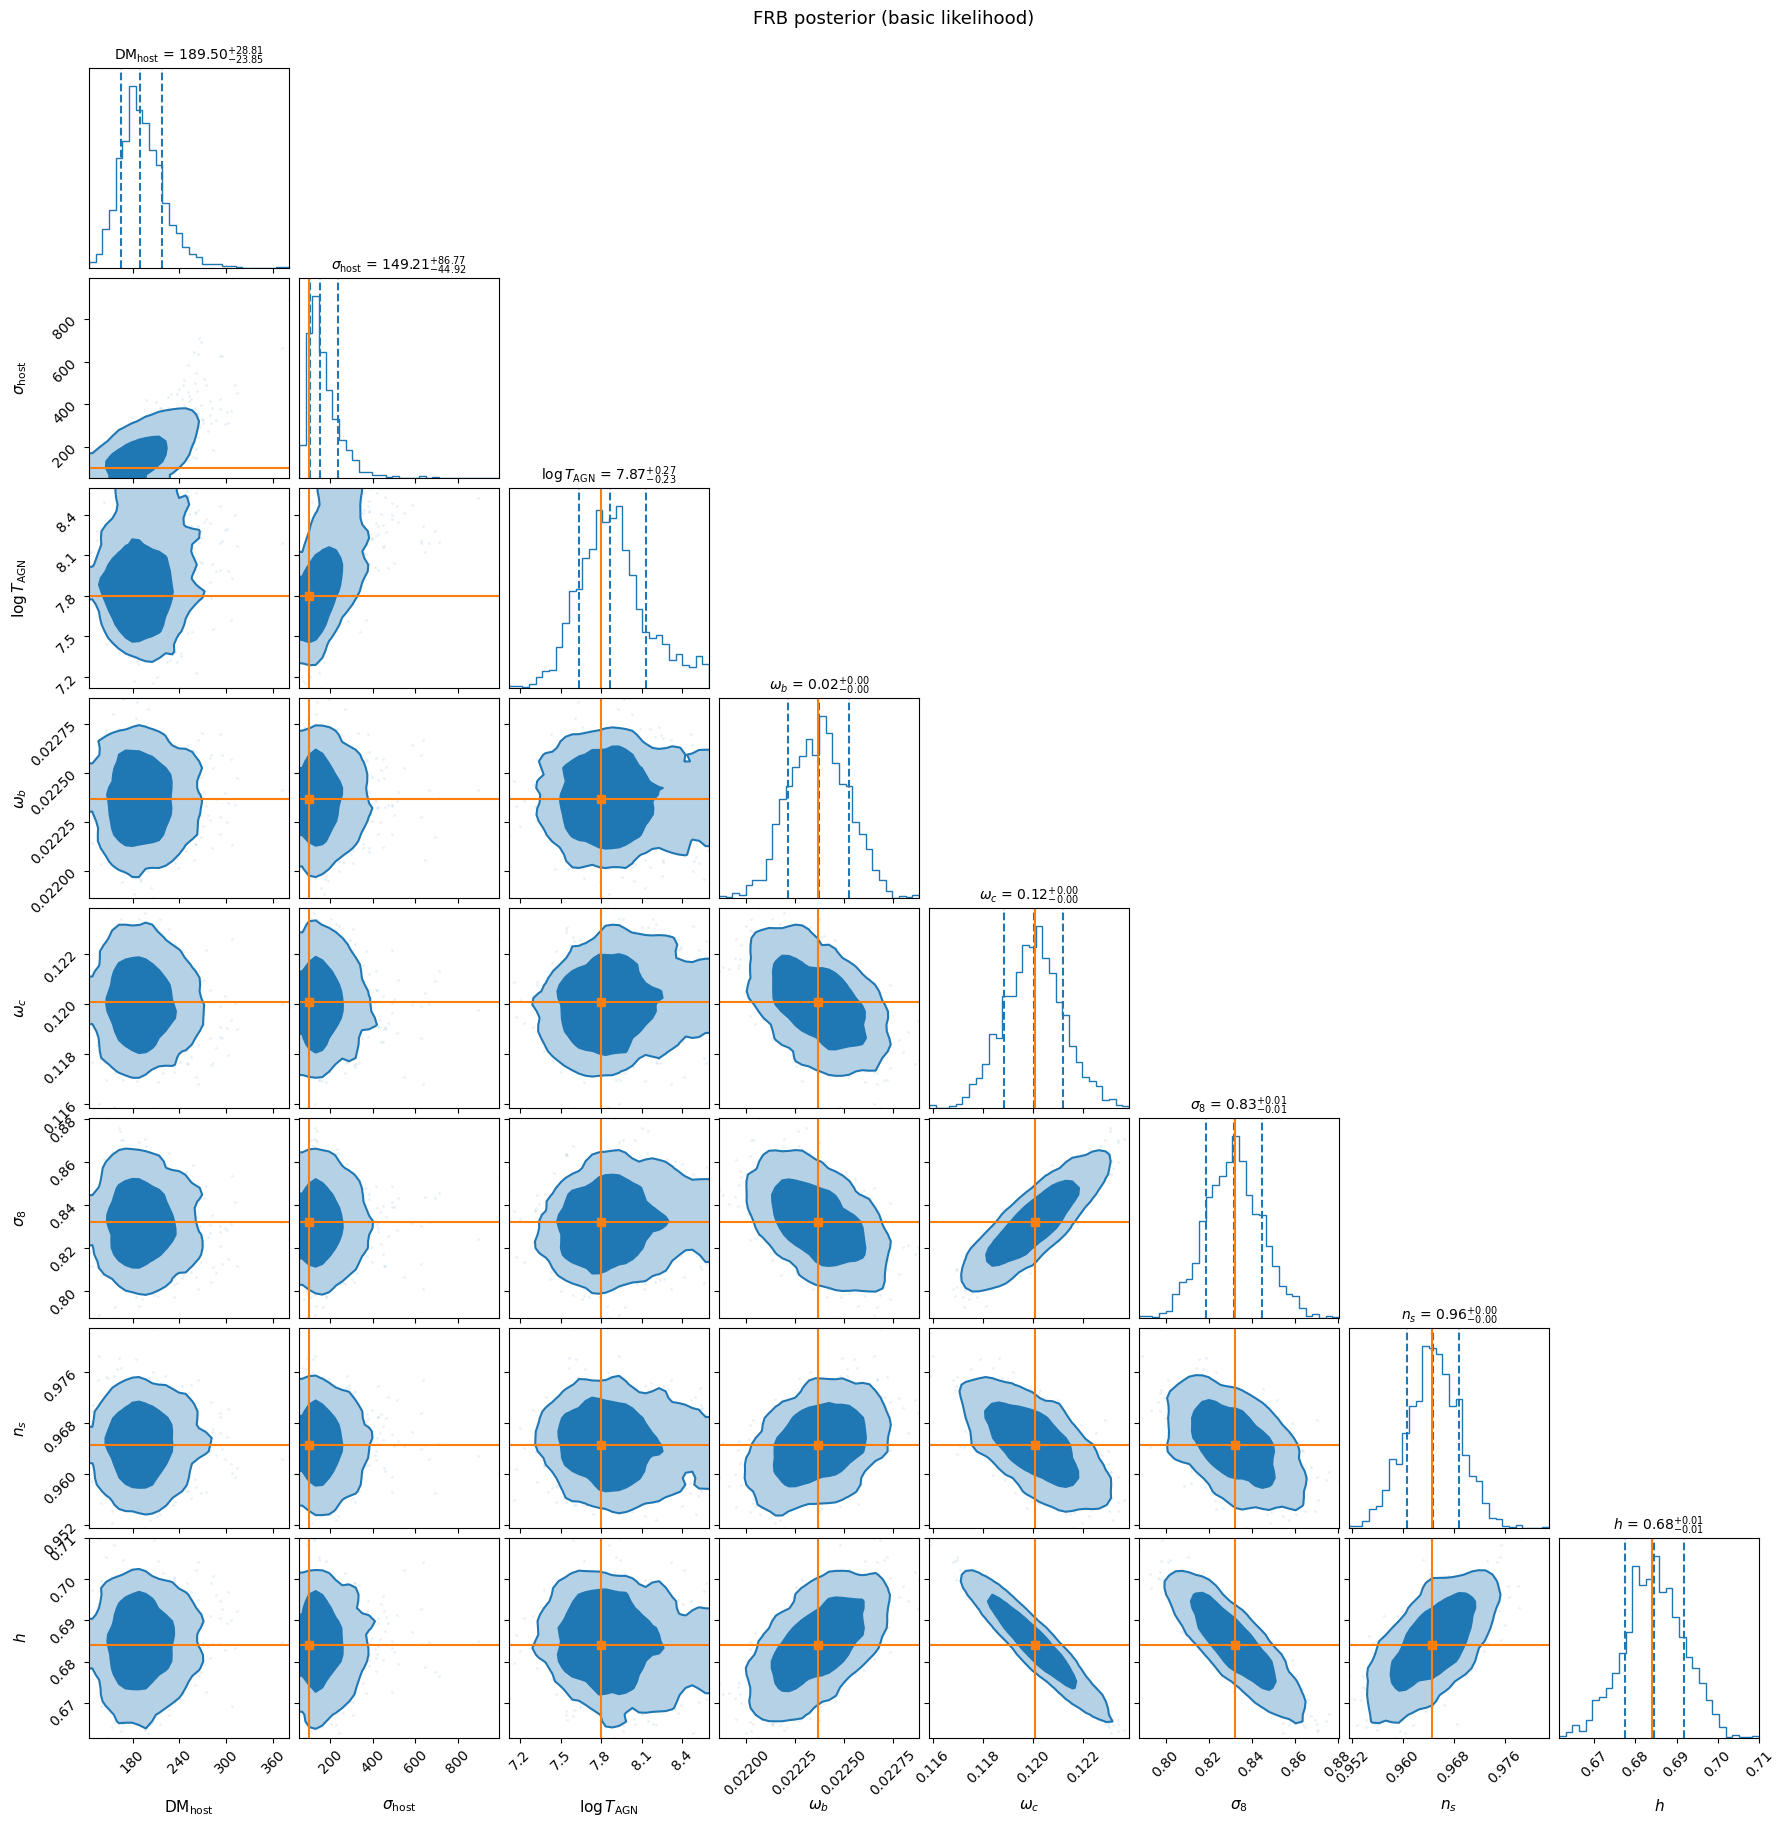

In [27]:
import corner

fig = corner.corner(
    flat_samples,
    labels=param_labels,
    truths=fiducial_params,
    truth_color='C1',
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={'fontsize': 10},
    label_kwargs={'fontsize': 11},
    smooth=1.0,
    bins=30,
    color='C0',
    fill_contours=True,
    levels=(0.68, 0.95),
)
fig.suptitle('FRB posterior (basic likelihood)', y=1.01, fontsize=13)
plt.show()